# Fraud Detection using XGBoost

 ## 0. Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, average_precision_score, precision_recall_curve,
                             precision_score, recall_score, make_scorer, fbeta_score)

## 1. Carga de datos

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

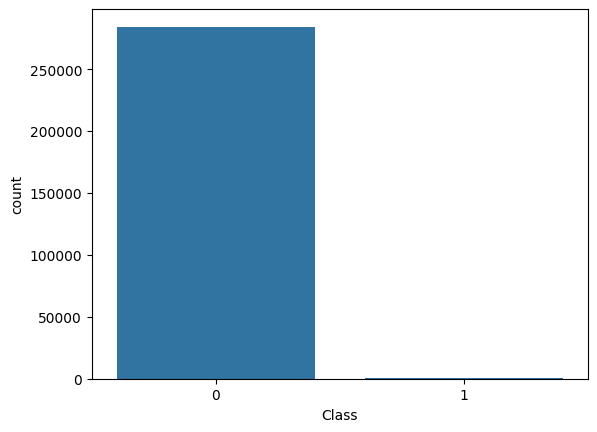



La base tiene 284315 transacciones normales y 492 fraudes, lo que representa un 0.17% del total.




In [3]:
df = pd.read_csv("creditcard.csv")

df.head()
df.info()
df.describe()
print("\n")
print(f"La base tiene {df.shape[0]} filas y {df.shape[1]} columnas")
print("\n")

# Ver el desbalanceo
sns.countplot(x='Class', data=df)
plt.show()
print("\n")
print(f"La base tiene {df['Class'].value_counts()[0]} transacciones normales y {df['Class'].value_counts()[1]} fraudes, lo que representa un {df['Class'].value_counts(normalize=True)[1]:.2%} del total.")
print("\n")

## 2. Data checking y limpieza

Valores faltantes por variable:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Filas duplicadas: 1081


Tras surprimir los duplicados, la base tiene 283726 filas y 31 columnas




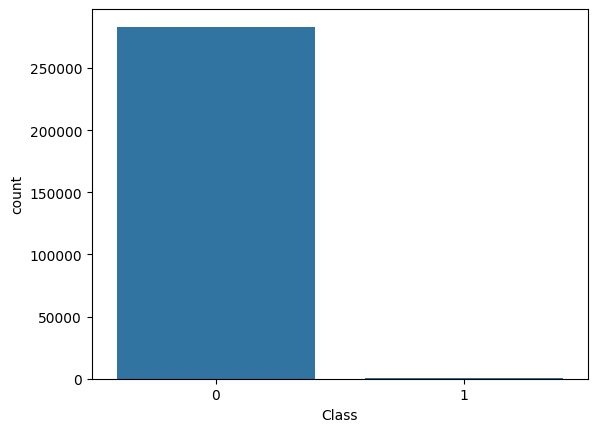



La base tiene 283253 transacciones normales y 473 fraudes, lo que representa un 0.17% del total.




In [4]:
print("Valores faltantes por variable:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())
df = df.drop_duplicates()

print("\n")
print(f"Tras surprimir los duplicados, la base tiene {df.shape[0]} filas y {df.shape[1]} columnas")
print("\n")

# Ver el desbalanceo ahora
sns.countplot(x='Class', data=df)
plt.show()
print("\n")
print(f"La base tiene {df['Class'].value_counts()[0]} transacciones normales y {df['Class'].value_counts()[1]} fraudes, lo que representa un {df['Class'].value_counts(normalize=True)[1]:.2%} del total.")
print("\n")

## 3. División inicial de los datos

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

# Cogemos un 80% de entrenamiento y un 20% de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42)

# Definimos qué columnas escalar
preprocessor = ColumnTransformer([('scaler', StandardScaler(), ['Time', 'Amount'])], remainder='passthrough')

# Validación cruzada (K-fold con K=5)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4. Primer modelo: Regresión Logística

### Regresión Logística

In [6]:
# Configurar el Pipeline
clf_pipeline_LR_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=5000,
        random_state=42))])


# Configurar la búsqueda de hiperparámetros
param_grid_LR_base = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2']}

grid_search_LR_base = GridSearchCV(
    estimator=clf_pipeline_LR_base,
    param_grid=param_grid_LR_base,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1)


# Entrenar la búsqueda
grid_search_LR_base.fit(X_train, y_train)
model_LR_base = grid_search_LR_base.best_estimator_
print(f"Mejores parámetros: {grid_search_LR_base.best_params_}")


# Predicción del modelo
y_pred_LR_base = model_LR_base.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_LR_base))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_LR_base))

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_log

Mejores parámetros: {'classifier__C': 1, 'classifier__penalty': 'l2'}

Confusion Matrix:
[[56641    10]
 [   39    56]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



### Ajuste del umbral de clasificación

In [7]:
# Vamos a usar y_proba porque de normal sklearn usa umbral = 0.5
y_oof_proba_LR = cross_val_predict(clf_pipeline_LR_base, X_train, y_train,cv=cv_strategy, method='predict_proba')[:, 1]
precision_LR, recall_LR, thresholds_LR = precision_recall_curve(y_train, y_oof_proba_LR)


# Mejor umbral según F2 (Beta = 2)
beta = 2
f2_scores_LR = (1 + beta**2) * (precision_LR[:-1] * recall_LR[:-1]) / ((beta**2 * precision_LR[:-1]) + recall_LR[:-1] + 1e-8)
best_idx_LR = np.argmax(f2_scores_LR)
best_threshold_LR = thresholds_LR[best_idx_LR]

print(f"Best threshold for F2 (validation): {best_threshold_LR:.4f}")
print(f"F2 Score alcanzado: {f2_scores_LR[best_idx_LR]:.4f}")


# Predicción del modelo
y_proba_LR = model_LR_base.predict_proba(X_test)[:, 1]
y_pred_LR_custom = (y_proba_LR > best_threshold_LR).astype(int)
f2_test_LR = fbeta_score(y_test, y_pred_LR_custom, beta=2)


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_LR_custom))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_LR_custom))

print(f"F2-Score: {f2_test_LR:.4f}")

Best threshold for F2 (validation): 0.0592
F2 Score alcanzado: 0.7986

Confusion Matrix:
[[56635    16]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.77      0.79        95

    accuracy                           1.00     56746
   macro avg       0.91      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746

F2-Score: 0.7783


### Curva ROC-AUC

ROC-AUC Score: 0.9563


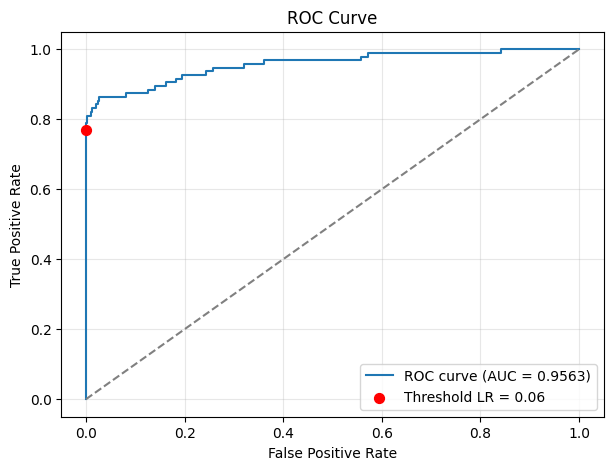

In [8]:
# Calcular métricas necesarias
roc_auc_LR = roc_auc_score(y_test, y_proba_LR)
print(f"ROC-AUC Score: {roc_auc_LR:.4f}")
fpr_LR, tpr_LR, _ = roc_curve(y_test, y_proba_LR)

# Calcular FPR y TPR específicos para tu umbral custom (el punto que quieres marcar)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_LR_custom).ravel()
fpr_custom = fp / (fp + tn)
tpr_custom = tp / (tp + fn)

# Graficar la curva ROC-AUC
plt.figure(figsize=(7, 5))
plt.plot(fpr_LR, tpr_LR, label=f"ROC curve (AUC = {roc_auc_LR:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')  # baseline
plt.scatter(fpr_custom, tpr_custom, color='red', s=50, zorder=5,
            label=f'Threshold LR = {best_threshold_LR:.2f}') # Marcar el punto del threshold elegido
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Curva PR-AUC

PR-AUC (Average Precision): 0.6923


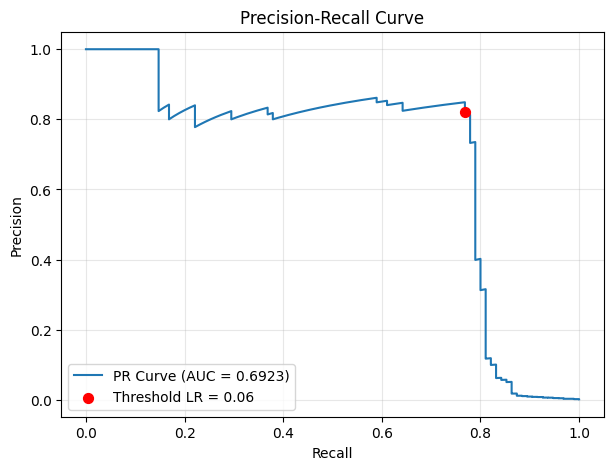

In [9]:
# Calcular métricas para la curva
pr_auc_LR = average_precision_score(y_test, y_proba_LR)
print(f"PR-AUC (Average Precision): {pr_auc_LR:.4f}")
precision_test_LR, recall_test_LR, _ = precision_recall_curve(y_test, y_proba_LR)
p_custom = precision_score(y_test, y_pred_LR_custom)
r_custom = recall_score(y_test, y_pred_LR_custom)

# Graficar la curva PR
plt.figure(figsize=(7, 5))
plt.plot(recall_test_LR, precision_test_LR, label=f'PR Curve (AUC = {pr_auc_LR:.4f})')

# Marcar el punto del threshold elegido
plt.scatter(r_custom, p_custom, color='red', s=50, zorder=5,
            label=f'Threshold LR = {best_threshold_LR:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

### Solución 1 para el desbalanceo: pesos en el modelo

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_log

Mejores parámetros: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}
Best threshold for F2 (validation): 0.9999
F2 Score alcanzado: 0.7977

Confusion Matrix:
[[56631    20]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.77      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.88      0.89     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC: 0.9657182620458226
F2-Score: 0.7717
PR-AUC (Average Precision): 0.6691


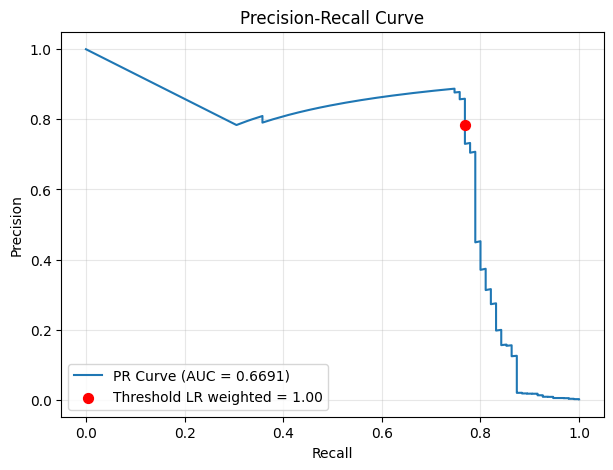

In [10]:
# Configurar el Pipeline
clf_pipeline_LR_weighted = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42))])


# Configurar la búsqueda de hiperparámetros
param_grid_LR_weighted = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2']}

grid_search_LR_weighted = GridSearchCV(
    estimator=clf_pipeline_LR_weighted,
    param_grid=param_grid_LR_weighted,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1)


# Entrenar la búsqueda
grid_search_LR_weighted.fit(X_train, y_train)
model_LR_weighted = grid_search_LR_weighted.best_estimator_
print(f"Mejores parámetros: {grid_search_LR_weighted.best_params_}")

y_oof_proba_LR_weighted = cross_val_predict(clf_pipeline_LR_weighted, X_train, y_train,cv=cv_strategy, method='predict_proba')[:, 1]
precision_LR_weighted, recall_LR_weighted, thresholds_LR_weighted = precision_recall_curve(y_train, y_oof_proba_LR_weighted)


# Mejor umbral según F2 (Beta = 2)
beta = 2
f2_scores_LR_weighted = (1 + beta**2) * (precision_LR_weighted[:-1] * recall_LR_weighted[:-1]) / ((beta**2 * precision_LR_weighted[:-1]) + recall_LR_weighted[:-1] + 1e-8)
best_idx_LR_weighted = np.argmax(f2_scores_LR_weighted)
best_threshold_LR_weighted = thresholds_LR_weighted[best_idx_LR_weighted]

print(f"Best threshold for F2 (validation): {best_threshold_LR_weighted:.4f}")
print(f"F2 Score alcanzado: {f2_scores_LR_weighted[best_idx_LR_weighted]:.4f}")


# Predicción del modelo
y_proba_LR_weighted = model_LR_weighted.predict_proba(X_test)[:, 1]
y_pred_LR_weighted = (y_proba_LR_weighted > best_threshold_LR_weighted).astype(int)
f2_test_LR_weighted = fbeta_score(y_test, y_pred_LR_weighted, beta=2)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_LR_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_LR_weighted))

print("ROC AUC:", roc_auc_score(y_test, y_proba_LR_weighted))

print(f"F2-Score: {f2_test_LR_weighted:.4f}")


# Graficar la curva PR-AUC (Average Precision)
pr_auc_LR_weighted = average_precision_score(y_test, y_proba_LR_weighted)
print(f"PR-AUC (Average Precision): {pr_auc_LR_weighted:.4f}")
precision_test_LR_weighted, recall_test_LR_weighted, _ = precision_recall_curve(y_test, y_proba_LR_weighted)
p_LR_weighted = precision_score(y_test, y_pred_LR_weighted)
r_LR_weighted = recall_score(y_test, y_pred_LR_weighted)

plt.figure(figsize=(7, 5))
plt.plot(recall_test_LR_weighted, precision_test_LR_weighted, label=f'PR Curve (AUC = {pr_auc_LR_weighted:.4f})')
plt.scatter(r_LR_weighted, p_LR_weighted, color='red', s=50, zorder=5,
            label=f'Threshold LR weighted = {best_threshold_LR_weighted:.2f}') # Marcar el punto del threshold elegido
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

### Solución 2: SMOTE (crea un fraude sintético)

In [12]:
# Aplicar SMOTE a los datos
smote = SMOTE(random_state=42)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Pc\Desktop\Proyectos Python\Fraud-Detection-using-XGBoost\env\Lib\site-packages\sklearn\linear_model\_log

Mejores parámetros: {'classifier__C': 0.01, 'classifier__penalty': 'l2'}
Best threshold for F2 (validation): 0.9997
F2 Score alcanzado: 0.7976

Confusion Matrix:
[[56631    20]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.77      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.88      0.89     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC: 0.9616897179313042
F2-Score: 0.7717
PR-AUC (Average Precision): 0.6587


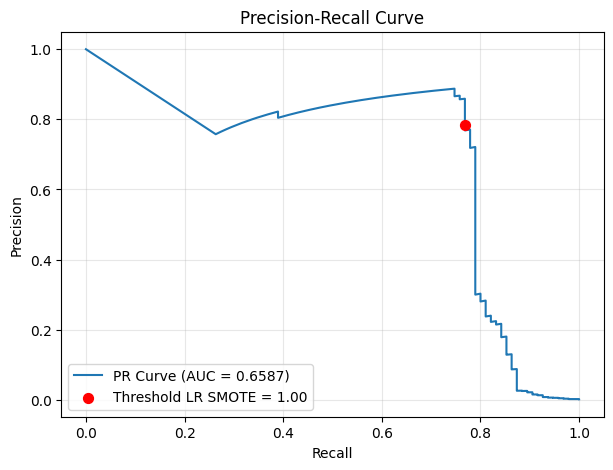

In [13]:
# Configurar el Pipeline
clf_pipeline_LR_SMOTE = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', LogisticRegression(
        max_iter=5000,
        random_state=42))])


# Configurar la búsqueda de hiperparámetros
param_grid_LR_SMOTE = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2']}

grid_search_LR_SMOTE = GridSearchCV(
    estimator=clf_pipeline_LR_SMOTE,
    param_grid=param_grid_LR_SMOTE,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1)


# Entrenar la búsqueda
grid_search_LR_SMOTE.fit(X_train, y_train)
model_LR_SMOTE = grid_search_LR_SMOTE.best_estimator_
print(f"Mejores parámetros: {grid_search_LR_SMOTE.best_params_}")

y_oof_proba_LR_SMOTE = cross_val_predict(clf_pipeline_LR_SMOTE, X_train, y_train,cv=cv_strategy, method='predict_proba')[:, 1]
precision_LR_SMOTE, recall_LR_SMOTE, thresholds_LR_SMOTE = precision_recall_curve(y_train, y_oof_proba_LR_SMOTE)


# Mejor umbral según F2 (Beta = 2)
beta = 2
f2_scores_LR_SMOTE = (1 + beta**2) * (precision_LR_SMOTE[:-1] * recall_LR_SMOTE[:-1]) / ((beta**2 * precision_LR_SMOTE[:-1]) + recall_LR_SMOTE[:-1] + 1e-8)
best_idx_LR_SMOTE = np.argmax(f2_scores_LR_SMOTE)
best_threshold_LR_SMOTE = thresholds_LR_SMOTE[best_idx_LR_SMOTE]

print(f"Best threshold for F2 (validation): {best_threshold_LR_SMOTE:.4f}")
print(f"F2 Score alcanzado: {f2_scores_LR_SMOTE[best_idx_LR_SMOTE]:.4f}")


# Predicción del modelo
y_proba_LR_SMOTE = model_LR_SMOTE.predict_proba(X_test)[:, 1]
y_pred_LR_SMOTE = (y_proba_LR_SMOTE > best_threshold_LR_SMOTE).astype(int)
f2_test_LR_SMOTE = fbeta_score(y_test, y_pred_LR_SMOTE, beta=2)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_LR_SMOTE))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_LR_SMOTE))

print("ROC AUC:", roc_auc_score(y_test, y_proba_LR_SMOTE))

print(f"F2-Score: {f2_test_LR_SMOTE:.4f}")


# Graficar la curva PR-AUC (Average Precision)
pr_auc_LR_SMOTE = average_precision_score(y_test, y_proba_LR_SMOTE)
print(f"PR-AUC (Average Precision): {pr_auc_LR_SMOTE:.4f}")
precision_test_LR_SMOTE, recall_test_LR_SMOTE, _ = precision_recall_curve(y_test, y_proba_LR_SMOTE)
p_LR_SMOTE = precision_score(y_test, y_pred_LR_SMOTE)
r_LR_SMOTE = recall_score(y_test, y_pred_LR_SMOTE)

plt.figure(figsize=(7, 5))
plt.plot(recall_test_LR_SMOTE, precision_test_LR_SMOTE, label=f'PR Curve (AUC = {pr_auc_LR_SMOTE:.4f})')
plt.scatter(r_LR_SMOTE, p_LR_SMOTE, color='red', s=50, zorder=5,
            label=f'Threshold LR SMOTE = {best_threshold_LR_SMOTE:.2f}') # Marcar el punto del threshold elegido
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

## 5. Segundo modelo: Random Forest

### Random Forest con pesos

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores parámetros: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best threshold for F2 (validation): 0.1400
F2 Score alcanzado: 0.8431

Confusion Matrix:
[[56635    16]
 [   19    76]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.80      0.81        95

    accuracy                           1.00     56746
   macro avg       0.91      0.90      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC: 0.953347039909176
F2-Score: 0.8051
PR-AUC (Average Precision): 0.8160


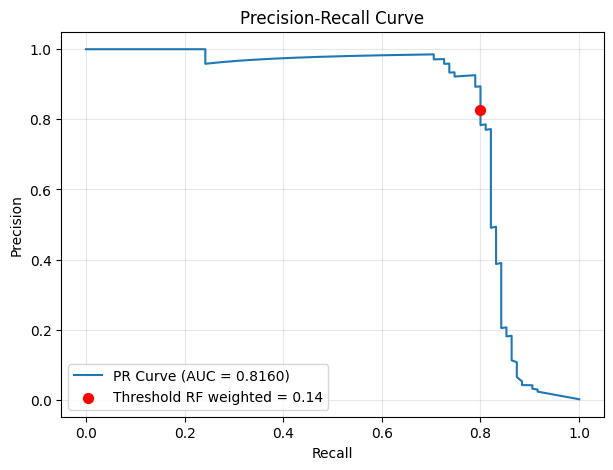

In [14]:
# Configurar el Pipeline
clf_pipeline_RF_weighted = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1))])


# Definir los hiperparámetros a probar y la métrica F2 como el objetivo
param_grid_RF_weighted = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, 15, 20],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2, 5],
    'classifier__max_features': ['sqrt']}

grid_search_RF_weighted = GridSearchCV(
    estimator=clf_pipeline_RF_weighted,
    param_grid=param_grid_RF_weighted,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1)


# Entrenar la búsqueda
grid_search_RF_weighted.fit(X_train, y_train)
model_RF_weighted = grid_search_RF_weighted.best_estimator_
print(f"Mejores parámetros: {grid_search_RF_weighted.best_params_}")

y_oof_proba_RF_weighted = cross_val_predict(clf_pipeline_RF_weighted, X_train, y_train,cv=cv_strategy, method='predict_proba')[:, 1]
precision_RF_weighted, recall_RF_weighted, thresholds_RF_weighted = precision_recall_curve(y_train, y_oof_proba_RF_weighted)


# Mejor umbral según F2 (Beta = 2)
beta = 2
f2_scores_RF_weighted = (1 + beta**2) * (precision_RF_weighted[:-1] * recall_RF_weighted[:-1]) / ((beta**2 * precision_RF_weighted[:-1]) + recall_RF_weighted[:-1] + 1e-8)
best_idx_RF_weighted = np.argmax(f2_scores_RF_weighted)
best_threshold_RF_weighted = thresholds_RF_weighted[best_idx_RF_weighted]

print(f"Best threshold for F2 (validation): {best_threshold_RF_weighted:.4f}")
print(f"F2 Score alcanzado: {f2_scores_RF_weighted[best_idx_RF_weighted]:.4f}")


# Predicción del modelo
y_proba_RF_weighted = model_RF_weighted.predict_proba(X_test)[:, 1]
y_pred_RF_weighted = (y_proba_RF_weighted > best_threshold_RF_weighted).astype(int)
f2_test_RF_weighted = fbeta_score(y_test, y_pred_RF_weighted, beta=2)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_RF_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_RF_weighted))

print("ROC AUC:", roc_auc_score(y_test, y_proba_RF_weighted))

print(f"F2-Score: {f2_test_RF_weighted:.4f}")


# Graficar la curva PR-AUC (Average Precision)
pr_auc_RF_weighted = average_precision_score(y_test, y_proba_RF_weighted)
print(f"PR-AUC (Average Precision): {pr_auc_RF_weighted:.4f}")
precision_test_RF_weighted, recall_test_RF_weighted, _ = precision_recall_curve(y_test, y_proba_RF_weighted)
p_RF_weighted = precision_score(y_test, y_pred_RF_weighted)
r_RF_weighted = recall_score(y_test, y_pred_RF_weighted)

plt.figure(figsize=(7, 5))
plt.plot(recall_test_RF_weighted, precision_test_RF_weighted, label=f'PR Curve (AUC = {pr_auc_RF_weighted:.4f})')
plt.scatter(r_RF_weighted, p_RF_weighted, color='red', s=50, zorder=5,
            label=f'Threshold RF weighted = {best_threshold_RF_weighted:.2f}') # Marcar el punto del threshold elegido
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

### Random Forest con SMOTE

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores parámetros: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Best threshold for F2 (validation): 0.5200
F2 Score alcanzado: 0.8356

Confusion Matrix:
[[56637    14]
 [   21    74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.78      0.81        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC: 0.9793767750650566
F2-Score: 0.7906
PR-AUC (Average Precision): 0.8102


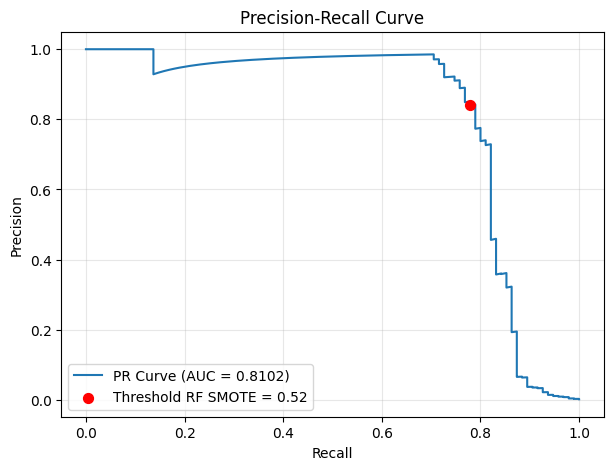

In [15]:
# Configurar el Pipeline
clf_pipeline_RF_SMOTE = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1))])


# Definir los hiperparámetros a probar y la métrica F2 como el objetivo
param_grid_RF_SMOTE = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, 15, 20],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2, 5],
    'classifier__max_features': ['sqrt']}

grid_search_RF_SMOTE = GridSearchCV(
    estimator=clf_pipeline_RF_SMOTE,
    param_grid=param_grid_RF_SMOTE,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1)


# Entrenar la búsqueda
grid_search_RF_SMOTE.fit(X_train, y_train)
model_RF_SMOTE = grid_search_RF_SMOTE.best_estimator_
print(f"Mejores parámetros: {grid_search_RF_SMOTE.best_params_}")

y_oof_proba_RF_SMOTE = cross_val_predict(clf_pipeline_RF_SMOTE, X_train, y_train,cv=cv_strategy, method='predict_proba')[:, 1]
precision_RF_SMOTE, recall_RF_SMOTE, thresholds_RF_SMOTE = precision_recall_curve(y_train, y_oof_proba_RF_SMOTE)


# Mejor umbral según F2 (Beta = 2)
beta = 2
f2_scores_RF_SMOTE = (1 + beta**2) * (precision_RF_SMOTE[:-1] * recall_RF_SMOTE[:-1]) / ((beta**2 * precision_RF_SMOTE[:-1]) + recall_RF_SMOTE[:-1] + 1e-8)
best_idx_RF_SMOTE = np.argmax(f2_scores_RF_SMOTE)
best_threshold_RF_SMOTE = thresholds_RF_SMOTE[best_idx_RF_SMOTE]

print(f"Best threshold for F2 (validation): {best_threshold_RF_SMOTE:.4f}")
print(f"F2 Score alcanzado: {f2_scores_RF_SMOTE[best_idx_RF_SMOTE]:.4f}")


# Predicción del modelo
y_proba_RF_SMOTE = model_RF_SMOTE.predict_proba(X_test)[:, 1]
y_pred_RF_SMOTE = (y_proba_RF_SMOTE > best_threshold_RF_SMOTE).astype(int)
f2_test_RF_SMOTE = fbeta_score(y_test, y_pred_RF_SMOTE, beta=2)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_RF_SMOTE))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_RF_SMOTE))

print("ROC AUC:", roc_auc_score(y_test, y_proba_RF_SMOTE))

print(f"F2-Score: {f2_test_RF_SMOTE:.4f}")


# Graficar la curva PR-AUC (Average Precision)
pr_auc_RF_SMOTE = average_precision_score(y_test, y_proba_RF_SMOTE)
print(f"PR-AUC (Average Precision): {pr_auc_RF_SMOTE:.4f}")
precision_test_RF_SMOTE, recall_test_RF_SMOTE, _ = precision_recall_curve(y_test, y_proba_RF_SMOTE)
p_RF_SMOTE = precision_score(y_test, y_pred_RF_SMOTE)
r_RF_SMOTE = recall_score(y_test, y_pred_RF_SMOTE)

plt.figure(figsize=(7, 5))
plt.plot(recall_test_RF_SMOTE, precision_test_RF_SMOTE, label=f'PR Curve (AUC = {pr_auc_RF_SMOTE:.4f})')
plt.scatter(r_RF_SMOTE, p_RF_SMOTE, color='red', s=50, zorder=5,
            label=f'Threshold RF SMOTE = {best_threshold_RF_SMOTE:.2f}') # Marcar el punto del threshold elegido
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

## 6. Tercer modelo: XGBoost

### XGBoost con pesos

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores parámetros: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__reg_alpha': 1, 'classifier__reg_lambda': 1, 'classifier__subsample': 0.8}
Best threshold for F2 (validation): 0.2054
F2 Score alcanzado: 0.8445

Confusion Matrix:
[[56643     8]
 [   20    75]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.79      0.84        95

    accuracy                           1.00     56746
   macro avg       0.95      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC: 0.9794286160229438
F2-Score: 0.8099
PR-AUC (Average Precision): 0.8277


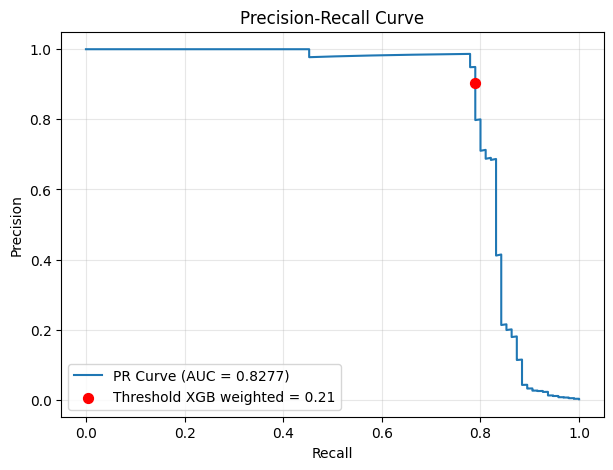

In [16]:
# Configurar la Pipeline
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]) # Calcular ratio de desbalanceo

clf_pipeline_XGB_weighted = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr'))])


# Definir los hiperparámetros a probar y la métrica F2 como el objetivo
param_grid_XGB_weighted = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 1],
    'classifier__reg_lambda': [1, 5, 10]}

grid_search_XGB_weighted = GridSearchCV(
    estimator=clf_pipeline_XGB_weighted,
    param_grid=param_grid_XGB_weighted,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1)


# Entrenar la búsqueda
grid_search_XGB_weighted.fit(X_train, y_train)
model_XGB_weighted = grid_search_XGB_weighted.best_estimator_
print(f"Mejores parámetros: {grid_search_XGB_weighted.best_params_}")

y_oof_proba_XGB_weighted = cross_val_predict(clf_pipeline_XGB_weighted, X_train, y_train,cv=cv_strategy, method='predict_proba')[:, 1]
precision_XGB_weighted, recall_XGB_weighted, thresholds_XGB_weighted = precision_recall_curve(y_train, y_oof_proba_XGB_weighted)


# Mejor umbral según F2 (Beta = 2)
beta = 2
f2_scores_XGB_weighted = (1 + beta**2) * (precision_XGB_weighted[:-1] * recall_XGB_weighted[:-1]) / ((beta**2 * precision_XGB_weighted[:-1]) + recall_XGB_weighted[:-1] + 1e-8)
best_idx_XGB_weighted = np.argmax(f2_scores_XGB_weighted)
best_threshold_XGB_weighted = thresholds_XGB_weighted[best_idx_XGB_weighted]

print(f"Best threshold for F2 (validation): {best_threshold_XGB_weighted:.4f}")
print(f"F2 Score alcanzado: {f2_scores_XGB_weighted[best_idx_XGB_weighted]:.4f}")


# Predicción del modelo
y_proba_XGB_weighted = model_XGB_weighted.predict_proba(X_test)[:, 1]
y_pred_XGB_weighted = (y_proba_XGB_weighted > best_threshold_XGB_weighted).astype(int)
f2_test_XGB_weighted = fbeta_score(y_test, y_pred_XGB_weighted, beta=2)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_XGB_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_XGB_weighted))

print("ROC AUC:", roc_auc_score(y_test, y_proba_XGB_weighted))

print(f"F2-Score: {f2_test_XGB_weighted:.4f}")


# Graficar la curva PR-AUC (Average Precision)
pr_auc_XGB_weighted = average_precision_score(y_test, y_proba_XGB_weighted)
print(f"PR-AUC (Average Precision): {pr_auc_XGB_weighted:.4f}")
precision_test_XGB_weighted, recall_test_XGB_weighted, _ = precision_recall_curve(y_test, y_proba_XGB_weighted)
p_XGB_weighted = precision_score(y_test, y_pred_XGB_weighted)
r_XGB_weighted = recall_score(y_test, y_pred_XGB_weighted)

plt.figure(figsize=(7, 5))
plt.plot(recall_test_XGB_weighted, precision_test_XGB_weighted, label=f'PR Curve (AUC = {pr_auc_XGB_weighted:.4f})')
plt.scatter(r_XGB_weighted, p_XGB_weighted, color='red', s=50, zorder=5,
            label=f'Threshold XGB weighted = {best_threshold_XGB_weighted:.2f}') # Marcar el punto del threshold elegido
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

### XGBoost con SMOTE

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores parámetros: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_alpha': 1, 'classifier__reg_lambda': 10, 'classifier__subsample': 1.0}
Best threshold for F2 (validation): 0.7750
F2 Score alcanzado: 0.8280

Confusion Matrix:
[[56637    14]
 [   21    74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.78      0.81        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC: 0.9769272433524192
F2-Score: 0.7906
PR-AUC (Average Precision): 0.8060


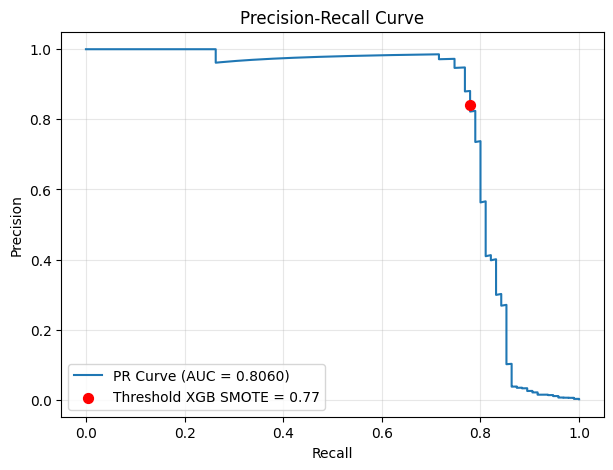

In [17]:
# Configurar el Pipeline
clf_pipeline_XGB_SMOTE = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr'))])


# Definir los hiperparámetros a probar y la métrica F2 como el objetivo
param_grid_XGB_SMOTE = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 1],
    'classifier__reg_lambda': [1, 5, 10]}

grid_search_XGB_SMOTE = GridSearchCV(
    estimator=clf_pipeline_XGB_SMOTE,
    param_grid=param_grid_XGB_SMOTE,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1)


# Entrenar la búsqueda
grid_search_XGB_SMOTE.fit(X_train, y_train)
model_XGB_SMOTE = grid_search_XGB_SMOTE.best_estimator_
print(f"Mejores parámetros: {grid_search_XGB_SMOTE.best_params_}")

y_oof_proba_XGB_SMOTE = cross_val_predict(clf_pipeline_XGB_SMOTE, X_train, y_train,cv=cv_strategy, method='predict_proba')[:, 1]
precision_XGB_SMOTE, recall_XGB_SMOTE, thresholds_XGB_SMOTE = precision_recall_curve(y_train, y_oof_proba_XGB_SMOTE)


# Mejor umbral según F2 (Beta = 2)
beta = 2
f2_scores_XGB_SMOTE = (1 + beta**2) * (precision_XGB_SMOTE[:-1] * recall_XGB_SMOTE[:-1]) / ((beta**2 * precision_XGB_SMOTE[:-1]) + recall_XGB_SMOTE[:-1] + 1e-8)
best_idx_XGB_SMOTE = np.argmax(f2_scores_XGB_SMOTE)
best_threshold_XGB_SMOTE = thresholds_XGB_SMOTE[best_idx_XGB_SMOTE]

print(f"Best threshold for F2 (validation): {best_threshold_XGB_SMOTE:.4f}")
print(f"F2 Score alcanzado: {f2_scores_XGB_SMOTE[best_idx_XGB_SMOTE]:.4f}")


# Predicción del modelo
y_proba_XGB_SMOTE = model_XGB_SMOTE.predict_proba(X_test)[:, 1]
y_pred_XGB_SMOTE = (y_proba_XGB_SMOTE > best_threshold_XGB_SMOTE).astype(int)
f2_test_XGB_SMOTE = fbeta_score(y_test, y_pred_XGB_SMOTE, beta=2)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_XGB_SMOTE))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_XGB_SMOTE))

print("ROC AUC:", roc_auc_score(y_test, y_proba_XGB_SMOTE))

print(f"F2-Score: {f2_test_XGB_SMOTE:.4f}")


# Graficar la curva PR-AUC (Average Precision)
pr_auc_XGB_SMOTE = average_precision_score(y_test, y_proba_XGB_SMOTE)
print(f"PR-AUC (Average Precision): {pr_auc_XGB_SMOTE:.4f}")
precision_test_XGB_SMOTE, recall_test_XGB_SMOTE, _ = precision_recall_curve(y_test, y_proba_XGB_SMOTE)
p_XGB_SMOTE = precision_score(y_test, y_pred_XGB_SMOTE)
r_XGB_SMOTE = recall_score(y_test, y_pred_XGB_SMOTE)

plt.figure(figsize=(7, 5))
plt.plot(recall_test_XGB_SMOTE, precision_test_XGB_SMOTE, label=f'PR Curve (AUC = {pr_auc_XGB_SMOTE:.4f})')
plt.scatter(r_XGB_SMOTE, p_XGB_SMOTE, color='red', s=50, zorder=5,
            label=f'Threshold XGB SMOTE = {best_threshold_XGB_SMOTE:.2f}') # Marcar el punto del threshold elegido
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

## Comparación Final

In [20]:
def precision_at_k(y_true, y_scores, k=100):
    top_k_idx = np.argsort(y_scores)[::-1][:k]
    if isinstance(y_true, pd.Series):
        return y_true.iloc[top_k_idx].sum() / k
    else:
        return y_true[top_k_idx].sum() / k

def expected_cost(y_true, y_pred, cost_fp=5, cost_fn=100):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * cost_fp + fn * cost_fn

models = {
    "Logistic Regression weighted": (y_pred_LR_weighted, y_proba_LR_weighted, f2_test_LR_weighted),
    "Logistic Regression with SMOTE": (y_pred_LR_SMOTE, y_proba_LR_SMOTE, f2_test_LR_SMOTE),
    "Random Forest weighted": (y_pred_RF_weighted, y_proba_RF_weighted, f2_test_RF_weighted),
    "Random Forest with SMOTE": (y_pred_RF_SMOTE, y_proba_RF_SMOTE, f2_test_RF_SMOTE),
    "XGBoost weighted": (y_pred_XGB_weighted, y_proba_XGB_weighted, f2_test_XGB_weighted),
    "XGBoost with SMOTE": (y_pred_XGB_SMOTE, y_proba_XGB_SMOTE, f2_test_XGB_SMOTE)}

results_list = []

for model_name, (y_pred, y_proba, f2_score_value) in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    row = {
        "Model": model_name,
        "Transacciones Correctas": tn,
        "Fraudes Detectados": tp,
        "Falsos Positivos": fp,
        "Falsos Negativos": fn,
        "Precisión": round(precision_score(y_test, y_pred), 3),
        "Fraud Detection Rate": round(recall_score(y_test, y_pred), 3),
        "F2-Score": round(f2_score_value, 3),
        "ROC_AUC": round(roc_auc_score(y_test, y_proba), 3),
        "PR_AUC": round(average_precision_score(y_test, y_proba), 3),
        "FPR": round(fp / (fp + tn), 5),
        "Precision@100": round(precision_at_k(y_test, y_proba, k=100), 3),
        "Expected Cost (€)": expected_cost(y_test, y_pred)}
    results_list.append(row)

results = pd.DataFrame(results_list)
results

,Model,Transacciones Correctas,Fraudes Detectados,Falsos Positivos,Falsos Negativos,Precisión,Fraud Detection Rate,F2-Score,ROC_AUC,PR_AUC,FPR,Precision@100,Expected Cost (€)
0,Logistic Regression weighted,56631,73,20,22,0.785,0.768,0.772,0.966,0.669,0.00035,0.73,2300
1,Logistic Regression with SMOTE,56631,73,20,22,0.785,0.768,0.772,0.962,0.659,0.00035,0.74,2300
2,Random Forest weighted,56635,76,16,19,0.826,0.800,0.805,0.953,0.816,0.00028,0.77,1980
3,Random Forest with SMOTE,56637,74,14,21,0.841,0.779,0.791,0.979,0.810,0.00025,0.76,2170
4,XGBoost weighted,56643,75,8,20,0.904,0.789,0.810,0.979,0.828,0.00014,0.76,2040
5,XGBoost with SMOTE,56637,74,14,21,0.841,0.779,0.791,0.977,0.806,0.00025,0.75,2170
